In [13]:
%pip install tensorflow matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [23]:
def create_time_series_data():
    time = np.arange(0, 100, 0.1)
    series = np.sin(time) + np.random.normal(0, 0.1, len(time))
    series = series + time /50
    return time, series

def create_dataset(data, time_step=10):
    X, Y = [], []
    for i in range(len(data) - time_step):
        a = data[i:(i + time_step), 0]
        X.append(a)
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

In [24]:
time, series = create_time_series_data()
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1))
time_step = 20
X, Y = create_dataset(series_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [25]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(50, activation='relu', input_shape=(time_step, 1)),
    tf.keras.layers.Dense(1)
])

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0440 - val_loss: 0.0109
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - val_loss: 7.7537e-04
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0010 - val_loss: 7.2887e-04
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0010 - val_loss: 7.0366e-04
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

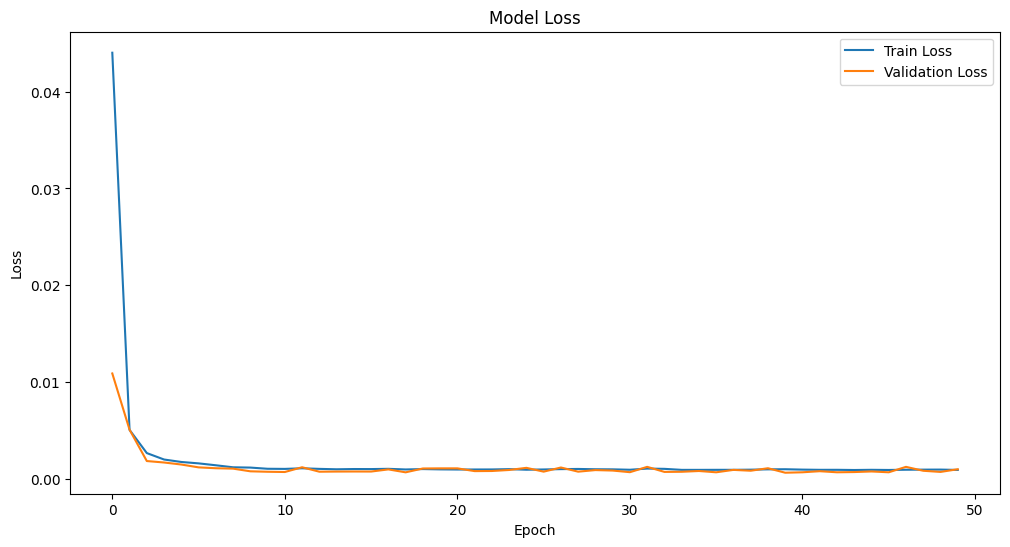

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [37]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_predictions = scaler.inverse_transform(train_predictions)
Y_train_ = scaler.inverse_transform(Y_train)
test_predictions = scaler.inverse_transform(test_predictions)
Y_test_ = scaler.inverse_transform(Y_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


ValueError: Expected 2D array, got 1D array instead:
array=[0.52912866 0.48800432 0.48725935 0.44004766 0.44879424 0.454284
 0.38660117 0.38246185 0.37221282 0.33119044 0.39271403 0.27876133
 0.30485366 0.26744508 0.24415228 0.20293197 0.20561153 0.16412071
 0.16521464 0.08540646 0.13712751 0.09222905 0.10794325 0.04808916
 0.0929258  0.         0.06509567 0.0405525  0.07077344 0.07949264
 0.07446608 0.06074495 0.05976933 0.09695413 0.10917311 0.12037197
 0.16704581 0.2055441  0.15925735 0.17435624 0.26231489 0.25890058
 0.25490823 0.27028092 0.36976275 0.34252808 0.39150019 0.41510358
 0.44856177 0.41208056 0.47724112 0.44791986 0.54412266 0.462586
 0.54968342 0.5160053  0.51593104 0.51420359 0.52994622 0.57530171
 0.55054594 0.56142856 0.58711332 0.51006719 0.52373994 0.51021514
 0.503873   0.48902257 0.46788925 0.4705656  0.40408797 0.39146121
 0.34124794 0.34607257 0.26384853 0.27191681 0.27479695 0.25135846
 0.22419567 0.21828972 0.16988629 0.17714414 0.14125132 0.14767271
 0.1337